# TRANSFORM

A Transformer is a neural network architecture that uses a self-attention mechanism to process input data in parallel and learn relationships between different parts of the input sequence.

### TRANSFORMER FUNCTION

A transformer function is a preprocessing function that converts raw data into a form suitable for machine learning algorithms.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

In [2]:
df = sns.load_dataset('titanic')
df = df[['age', 'fare', 'survived']]
df.head()

,age,fare,survived
0,22.0,7.2500,0
1,38.0,71.2833,1
2,26.0,7.9250,1
3,35.0,53.1000,1
4,35.0,8.0500,0


In [3]:
df.isnull().sum()

age         177
fare          0
survived      0
dtype: int64

In [4]:
df['age'] = df['age'].fillna(df['age'].mean())
df.isnull().sum()

age         0
fare        0
survived    0
dtype: int64

In [5]:
X = df[['age', 'fare']]
y = df['survived']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=42)

In [7]:
print(X_train.head())

      age     fare
331  45.5  28.5000
733  23.0  13.0000
382  32.0   7.9250
704  26.0   7.8542
813   6.0  31.2750


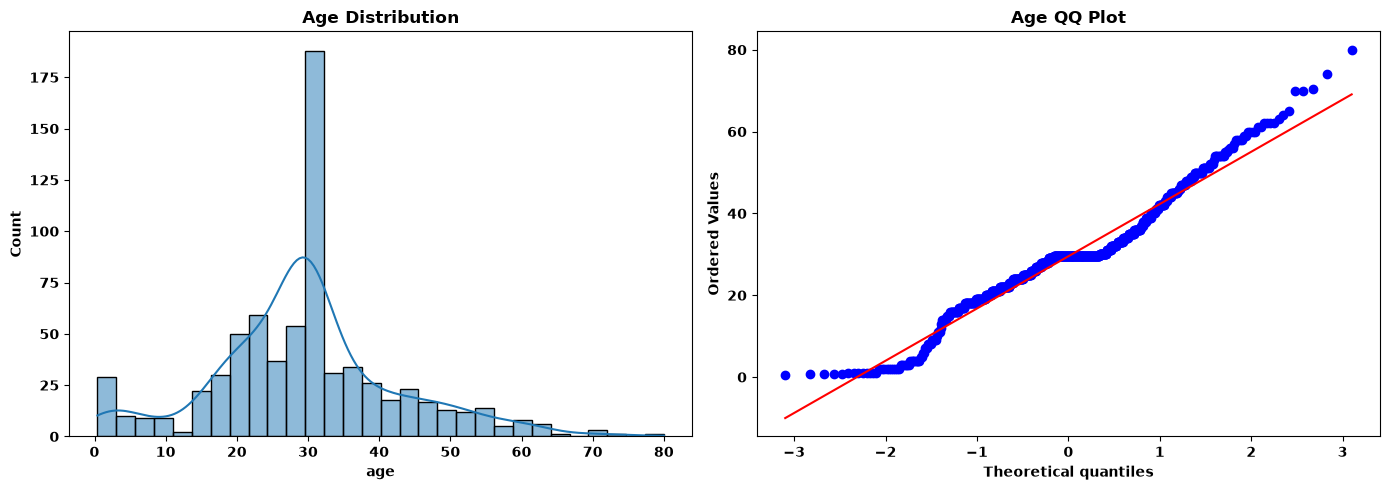

In [9]:
plt.figure(figsize=(14, 5))

# PDF / Histogram
plt.subplot(1, 2, 1)
sns.histplot(X_train['age'], kde=True, bins=30)
plt.title('Age Distribution')

# QQ Plot
plt.subplot(1, 2, 2)
stats.probplot(X_train['age'], dist='norm', plot=plt)
plt.title('Age QQ Plot')

plt.tight_layout()
plt.show()

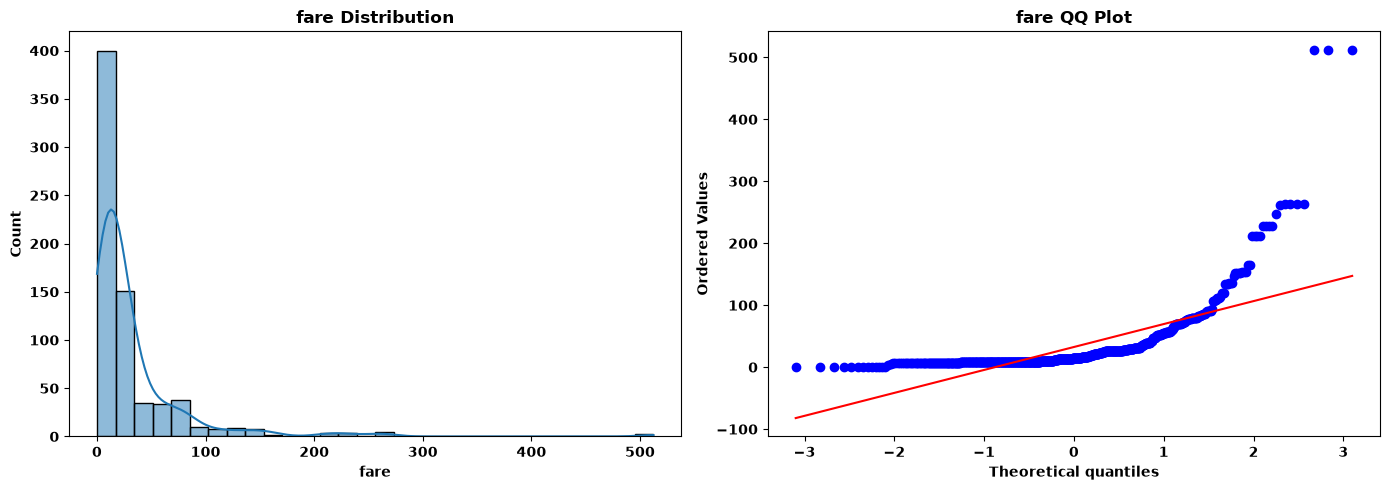

In [10]:
plt.figure(figsize=(14, 5))

# PDF / Histogram
plt.subplot(1, 2, 1)
sns.histplot(X_train['fare'], kde=True, bins=30)
plt.title('fare Distribution')

# QQ Plot
plt.subplot(1, 2, 2)
stats.probplot(X_train['fare'], dist='norm', plot=plt)
plt.title('fare QQ Plot')

plt.tight_layout()
plt.show()

In [11]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [12]:
clf.fit(X_train, y_train)
clf2.fit(X_train, y_train)

# predict
y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)

#  Accuracy Score 
print("Accuracy LR: ", accuracy_score(y_test,y_pred))
print("Accuracy DT: ", accuracy_score(y_test,y_pred1))

Accuracy LR:  0.6480446927374302
Accuracy DT:  0.6759776536312849


Now applying Function Transform to make normal distribution dataset 

In [13]:
trf = FunctionTransformer(func=np.log1p)

In [14]:
X_train_tranformed = trf.fit_transform(X_train)
X_test_tranformed = trf.fit_transform(X_test)

In [17]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_tranformed, y_train)
clf2.fit(X_train_tranformed, y_train)

# predict
y_pred = clf.predict(X_test_tranformed)
y_pred1 = clf2.predict(X_test_tranformed)

#  Accuracy Score 
print("Accuracy LR: ", accuracy_score(y_test,y_pred))
print("Accuracy DT: ", accuracy_score(y_test,y_pred1))

Accuracy LR:  0.6815642458100558
Accuracy DT:  0.6759776536312849


In [19]:
# Cross validate the dataset
X_transformed = trf.fit_transform(X)
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print('LR: ', np.mean(cross_val_score(clf, X_transformed, y, scoring='accuracy', cv=10)))
print('DT: ', np.mean(cross_val_score(clf2, X_transformed, y, scoring='accuracy', cv=10)))

LR:  0.678027465667915
DT:  0.6621847690387017


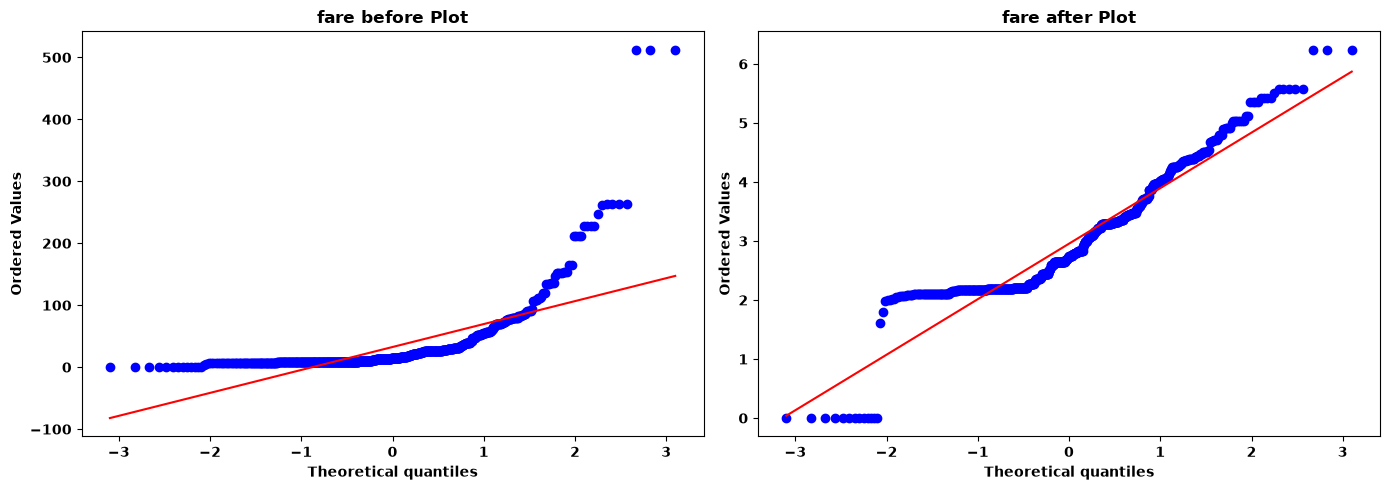

In [20]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
stats.probplot(X_train['fare'], dist='norm', plot=plt)
plt.title('fare before Plot')

plt.subplot(1, 2, 2)
stats.probplot(X_train_tranformed['fare'], dist='norm', plot=plt)
plt.title('fare after Plot')

plt.tight_layout()
plt.show()

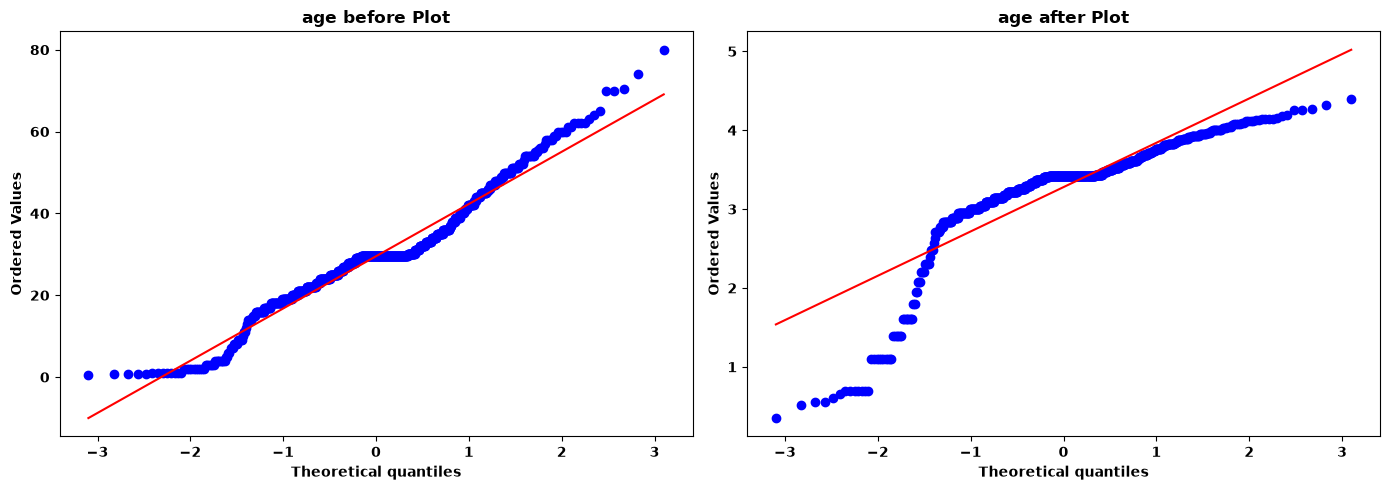

In [21]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
stats.probplot(X_train['age'], dist='norm', plot=plt)
plt.title('age before Plot')

plt.subplot(1, 2, 2)
stats.probplot(X_train_tranformed['age'], dist='norm', plot=plt)
plt.title('age after Plot')

plt.tight_layout()
plt.show()

After applying this transformation to the **age** feature, the model's performance may sometimes become worse instead of better. This happens because the **age** data is already right-skewed, and forcing a transformation on a feature that doesn't need it can negatively affect the results.


Let's do this. Instead of applying the log transformation to both columns, we'll apply it only to the **`fare`** feature and leave the **`age`** feature unchanged.

In [ ]:
# log function
trf2 = ColumnTransformer([('log', FunctionTransformer(np.log1p), ['fare'])], remainder='passthrough')

X_train_tranformed2 = trf2.fit_transform(X_train)
X_test_tranformed2 = trf2.fit_transform(X_test)

In [23]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_tranformed2, y_train)
clf2.fit(X_train_tranformed2, y_train)

# predict
y_pred = clf.predict(X_test_tranformed2)
y_pred1 = clf2.predict(X_test_tranformed2)

#  Accuracy Score 
print("Accuracy LR: ", accuracy_score(y_test,y_pred))
print("Accuracy DT: ", accuracy_score(y_test,y_pred1))

Accuracy LR:  0.6703910614525139
Accuracy DT:  0.6759776536312849


In [24]:
# Cross validate the dataset
X_transformed2 = trf2.fit_transform(X)
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print('LR: ', np.mean(cross_val_score(clf, X_transformed2, y, scoring='accuracy', cv=10)))
print('DT: ', np.mean(cross_val_score(clf2, X_transformed2, y, scoring='accuracy', cv=10)))

LR:  0.6712609238451936
DT:  0.6621847690387016


In [34]:
def apply_transform(tranform):
    X = df[['age', 'fare']]
    y = df['survived']

    trf = ColumnTransformer([('log', FunctionTransformer(tranform), ['fare'])], remainder='passthrough')

    X_trans = trf.fit_transform(X)

    clf = LogisticRegression()

    print('LR accuracy : ', np.mean(cross_val_score(clf, X_trans, y, scoring='accuracy', cv=10)))

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    stats.probplot(X['fare'], dist='norm', plot=plt)
    plt.title('Fare before transform')

    plt.subplot(1, 2, 2)
    stats.probplot(X_trans[:,0], dist='norm', plot=plt)
    plt.title('Fare after transform')

    plt.tight_layout()
    plt.show()
        


LR accuracy :  0.6589013732833957


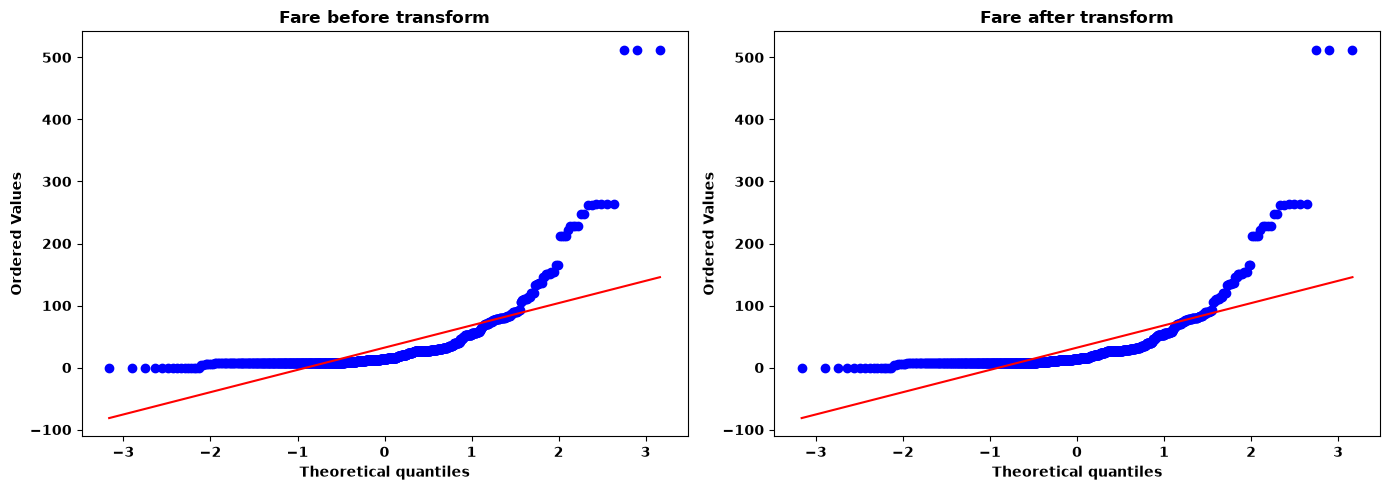

In [35]:
apply_transform(lambda x: x)

LR accuracy :  0.6431335830212235


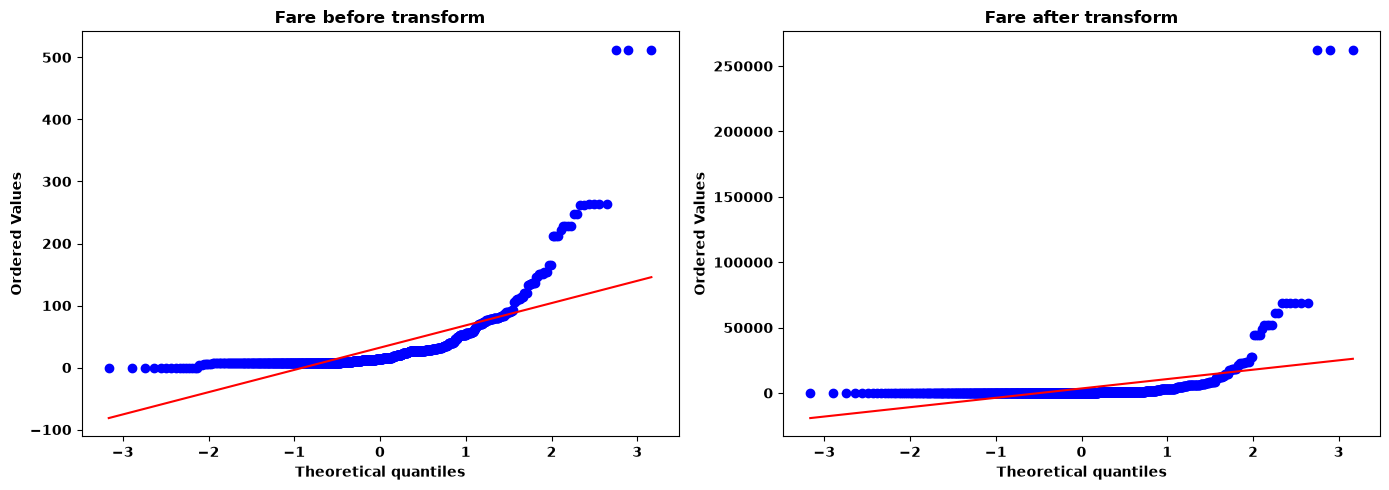

In [ ]:
# Square func
apply_transform(lambda x: x**2)

LR accuracy :  0.6589013732833957


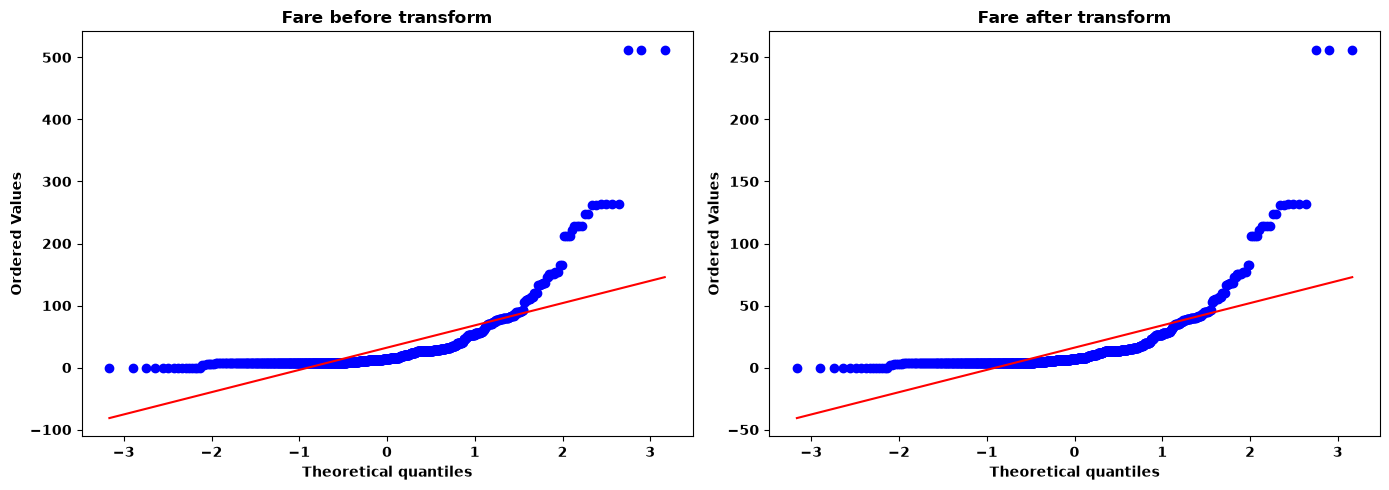

In [ ]:
# Square root func
apply_transform(lambda x: x**1/2)

LR accuracy :  0.61729088639201


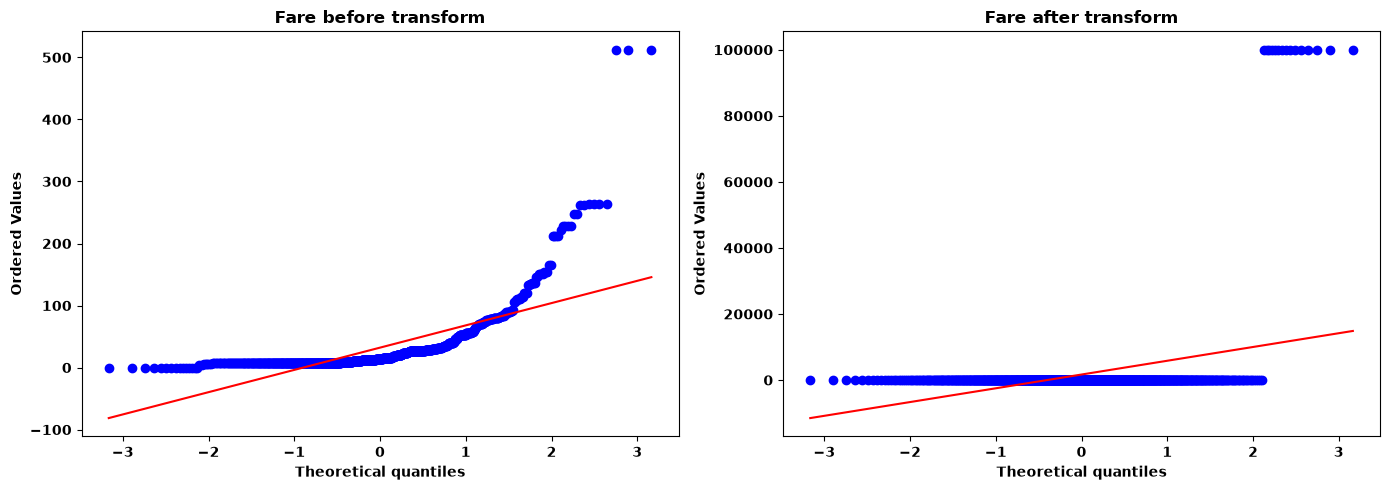

In [ ]:
# reciprocal func
apply_transform(lambda x: 1/(x+0.00001))